In [1]:
import pandas as pd
df= pd.read_csv("student-scores.csv")
df.head()


,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [4]:
df = df.drop(['id', 'first_name', 'last_name', 'email'], axis=1)


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['career_aspiration'] = le.fit_transform(df['career_aspiration'])
df['part_time_job'] = df['part_time_job'].astype(int)
df['extracurricular_activities'] = df['extracurricular_activities'].astype(int)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   gender                      2000 non-null   int64
 1   part_time_job               2000 non-null   int64
 2   absence_days                2000 non-null   int64
 3   extracurricular_activities  2000 non-null   int64
 4   weekly_self_study_hours     2000 non-null   int64
 5   career_aspiration           2000 non-null   int64
 6   math_score                  2000 non-null   int64
 7   history_score               2000 non-null   int64
 8   physics_score               2000 non-null   int64
 9   chemistry_score             2000 non-null   int64
 10  biology_score               2000 non-null   int64
 11  english_score               2000 non-null   int64
 12  geography_score             2000 non-null   int64
dtypes: int64(13)
memory usage: 203.3 KB


In [8]:
df['final_grade'] = df[['math_score','history_score','physics_score',
                        'chemistry_score','biology_score','english_score',
                        'geography_score']].mean(axis=1)


In [9]:
X = df[['gender',
        'part_time_job',
        'absence_days',
        'extracurricular_activities',
        'weekly_self_study_hours',
        'career_aspiration']]

y = df['final_grade']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression:")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression:
R2: 0.2809326566487109
MAE: 4.480561631416089
RMSE: 5.557202389000572


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest:
R2: 0.3658282525554615
MAE: 4.045165006957327
RMSE: 5.218850738652699


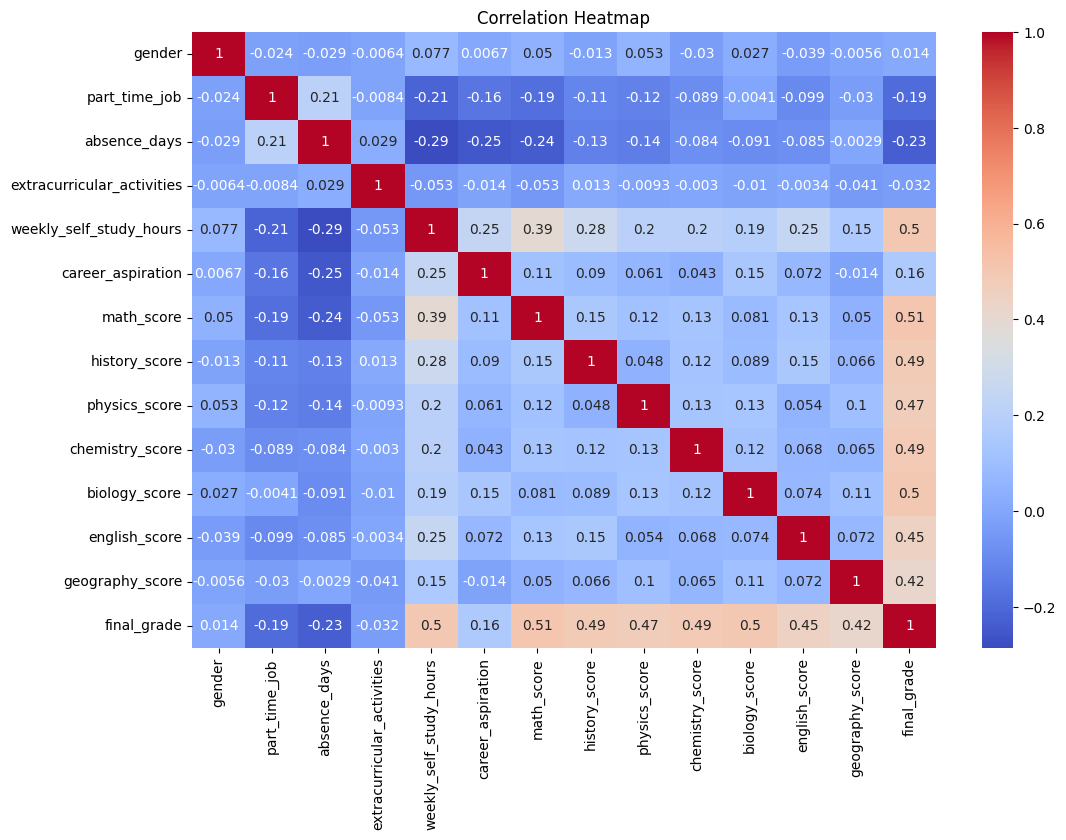

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


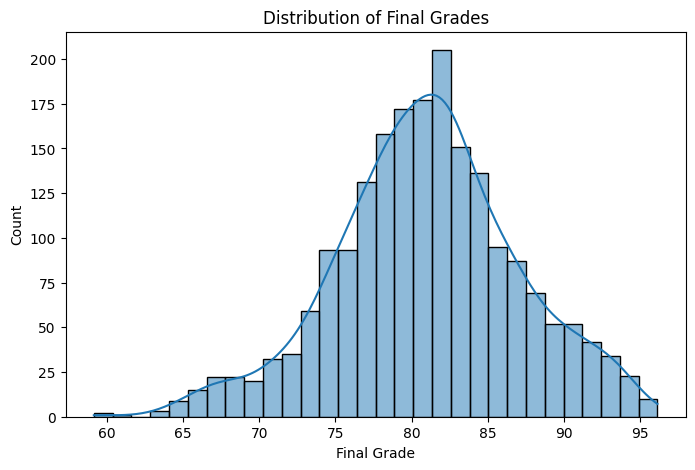

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['final_grade'], kde=True, bins=30)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()


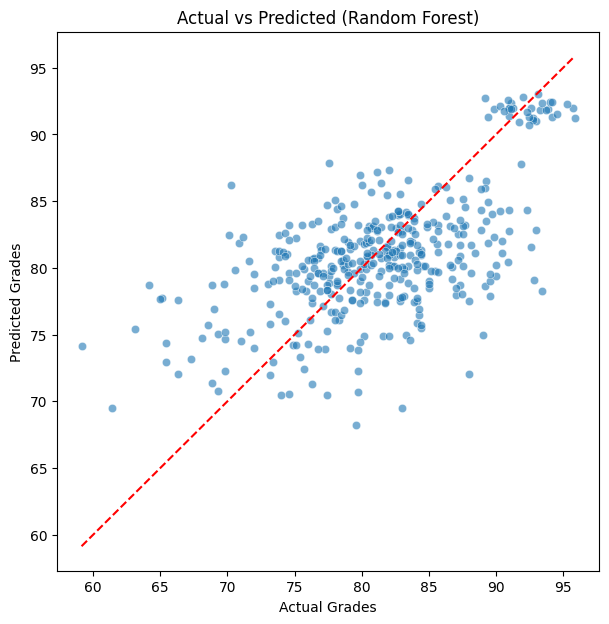

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted (Random Forest)")

min_val = min(np.min(y_test), np.min(y_pred_rf))
max_val = max(np.max(y_test), np.max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()


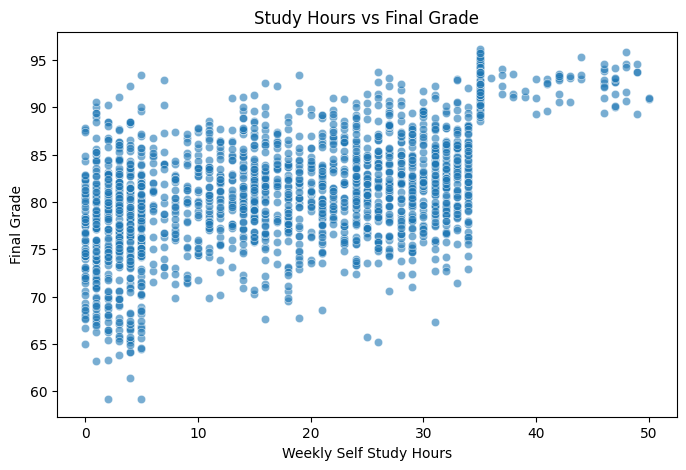

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['weekly_self_study_hours'], y=df['final_grade'], alpha=0.6)
plt.title("Study Hours vs Final Grade")
plt.xlabel("Weekly Self Study Hours")
plt.ylabel("Final Grade")
plt.show()


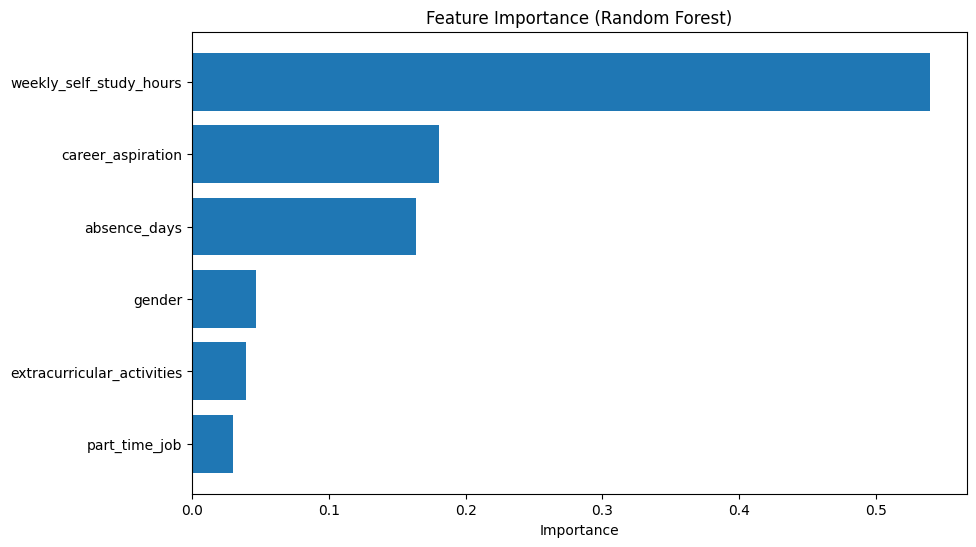

In [17]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features[indices], importances[indices])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


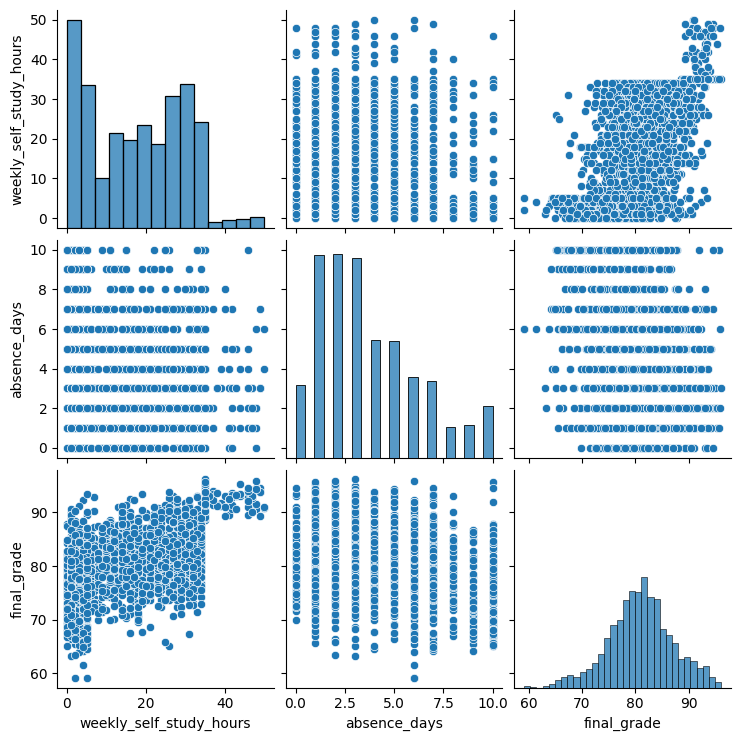

In [19]:
sns.pairplot(df[['weekly_self_study_hours','absence_days','final_grade']])
plt.show()




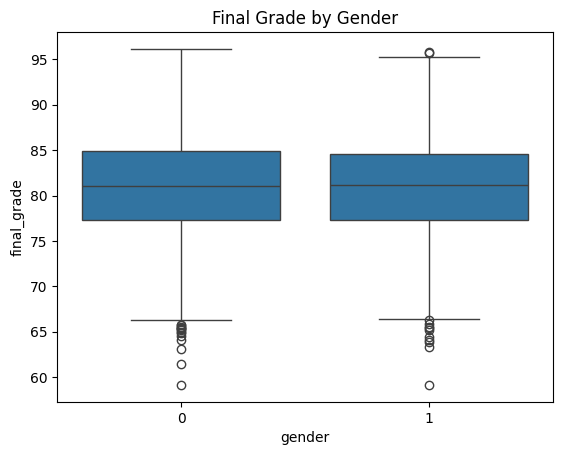

In [20]:
sns.boxplot(x='gender', y='final_grade', data=df)
plt.title("Final Grade by Gender")
plt.show()


In [21]:
import joblib
joblib.dump(rf, "student_score_model.pkl")


['student_score_model.pkl']